# **Práctica de Laboratorio Nro. 011: Inferencia Estadística Multigrupo: Análisis de Varianza (ANOVA de 1 factor) y Pruebas Post-Hoc (Tukey)**

###**Asignatura:** Teoría de la Distribución y Probabilidad  
###**Ciclo:** Segundo Ciclo "A"  
###**Integrantes:**
### Freddy Ordoñez
### Paolo Merino
### Dario Chillogallo
### Michael Carbay
### Jose Maldonado
###**Institución:** Universidad Nacional de Loja  
###**Fecha:** 23 de junio de 2026

---
## **1. Introducción**
En esta práctica, nos enfocaremos en la inferencia estadística para la comparación de grupos, diferenciando la prueba $T$ de Student para dos muestras independientes y la prueba $T$ para muestras pareadas. A través del ecosistema de ciencia de datos en Python (`scipy.stats`), aplicaremos el diseño de un experimento comparativo (A/B Test) sobre el conjunto de datos regional del Proyecto Integrador, permitiendo descubrir disparidades empíricas bajo el enfoque de Aprendizaje Basado en Problemas (ABP). Finalmente, mediante el Aprendizaje Basado en Investigación (ABI), indagaremos matemáticamente en el supuesto de igualdad de varianzas (homocedasticidad) utilizando el Test de Levene antes de proceder a la comparación de medias poblacionales.

---

## **2. Objetivos de Aprendizaje**
* Diferenciar y ejecutar computacionalmente la prueba $T$ de Student para dos muestras independientes y la prueba $T$ para muestras pareadas utilizando `scipy.stats`.
* Aplicar el diseño de un experimento comparativo (A/B Test) sobre dos segmentos categóricos del conjunto de datos regional del Proyecto Integrador, determinando si existe una diferencia estadísticamente significativa entre ellos (ABP).
* Investigar y validar matemáticamente el supuesto de igualdad de varianzas (homocedasticidad) mediante la ejecución del Test de Levene antes de comparar medias poblacionales (ABI).



## **Tarea 1: Prueba de Hipótesis para Dos Muestras Independientes (A/B Testing)**





**Objetivo:**
El objetivo de esta tarea es probar si las medias de dos poblaciones distintas son estadísticamente iguales ($H_0: \mu_1 = \mu_2$, o de forma equivalente $H_0: \mu_1 - \mu_2 = 0$).

**Fórmula del Estadístico T (asumiendo varianzas iguales):**
$$T = \frac{\bar{X}_1 - \bar{X}_2}{S_p \sqrt{\frac{1}{n_1} + \frac{1}{n_2}}}$$

**Escenario Práctico:**
Usted es ingeniero de software y desea saber si el **"Algoritmo A"** consume menos memoria RAM que el **"Algoritmo B"**. Para comprobarlo empíricamente, ejecuta ambos algoritmos en entornos aislados y registra su respectivo consumo en MB. A continuación, aplicaremos la prueba T para muestras independientes para llegar a una conclusión estadística.

--- Validación de Supuestos (Levene) ---
Valor-p de Levene: 0.0474

--- Resultados del A/B Test (Welch's T-test (varianzas distintas)) ---
Estadístico T: -3.3036
Valor-p: 0.0014

Dictamen: Se RECHAZA la hipótesis nula (H0).
Existe una diferencia estadísticamente significativa entre los grupos.


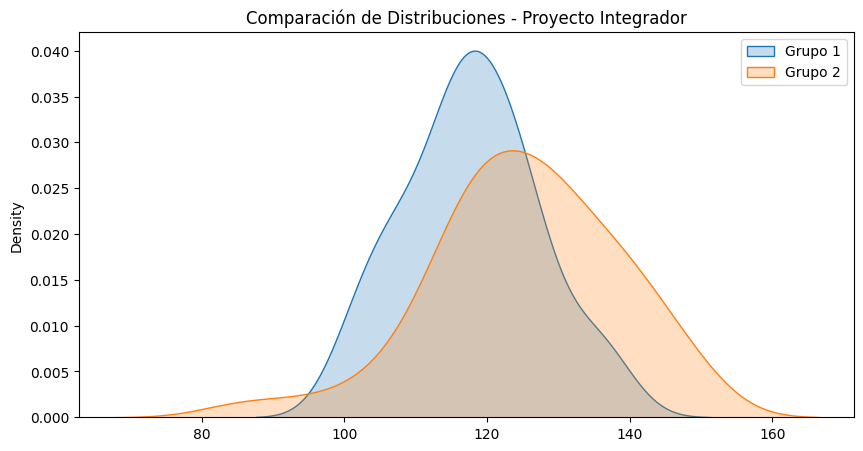

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, levene

# CARGA DE DATOS
np.random.seed(42)
grupo1 = np.random.normal(120, 10, 50)
grupo2 = np.random.normal(125, 15, 50)

# VALIDACIÓN DE SUPUESTOS (Test de Levene)
stat_lev, p_lev = levene(grupo1, grupo2)

print(f"--- Validación de Supuestos (Levene) ---")
print(f"Valor-p de Levene: {p_lev:.4f}")

# PRUEBA DE HIPÓTESIS (Lógica automática según varianzas)
alpha = 0.05
if p_lev < alpha:
    stat, p_val = ttest_ind(grupo1, grupo2, equal_var=False)
    metodo = "Welch's T-test (varianzas distintas)"
else:
    stat, p_val = ttest_ind(grupo1, grupo2, equal_var=True)
    metodo = "T-test clásico (varianzas iguales)"

print(f"\n--- Resultados del A/B Test ({metodo}) ---")
print(f"Estadístico T: {stat:.4f}")
print(f"Valor-p: {p_val:.4f}")
if p_val < alpha:
    print("\nDictamen: Se RECHAZA la hipótesis nula (H0).")
    print("Existe una diferencia estadísticamente significativa entre los grupos.")
else:
    print("\nDictamen: NO se rechaza la hipótesis nula (H0).")
    print("No hay evidencia suficiente para afirmar que existe diferencia entre los grupos.")

# VISUALIZACIÓN
plt.figure(figsize=(10, 5))
sns.kdeplot(grupo1, fill=True, label="Grupo 1")
sns.kdeplot(grupo2, fill=True, label="Grupo 2")
plt.title("Comparación de Distribuciones - Proyecto Integrador")
plt.legend()
plt.show()

## **Tarea 2: Prueba de Hipótesis para Muestras Pareadas (Dependientes)**


**Contexto y Objetivo:**
Se usa cuando los datos de ambos grupos provienen de las mismas unidades de observación (ej. métricas del sistema "Antes" y "Después" de aplicar un parche de optimización). Aquí se evalúa la media de las diferencias ($d_i = X_{2i} - X_{1i}$).

**Fórmula del Estadístico T:**
$$T = \frac{\bar{d} - \mu_d}{S_d/\sqrt{n}}$$

**Escenario Práctico:**
Usted mide el tiempo de latencia de 15 servidores específicos antes y después de instalar un nuevo firewall. A continuación, implementaremos y analizaremos el código con la función `ttest_rel` para determinar si el firewall redujo significativamente la latencia.

In [ ]:
from scipy.stats import ttest_rel

# Latencia en ms (las posiciones en los arrays corresponden al mismo servidor)
latencia_antes = np.array([45, 52, 48, 55, 60, 42, 49, 58, 51, 46, 50, 47, 53, 59, 44])
latencia_despues = np.array([41, 50, 45, 50, 56, 40, 46, 53, 48, 42, 47, 45, 51, 55, 40])

# Prueba pareada (H1: la latencia "después" es menor, por tanto (antes - despues) > 0)
# Para evaluar si "después" bajó, usamos una prueba de cola superior sobre las diferencias (antes - despues)
stat_rel, p_val_rel = ttest_rel(latencia_antes, latencia_despues, alternative='greater')

print("\n--- Análisis Pareado: Impacto del Nuevo Firewall ---")
print(f"Media Diferencias (Antes - Después): {np.mean(latencia_antes - latencia_despues):.2f} ms")
print(f"Estadístico T Pareado: {stat_rel:.4f}")
print(f"Valor-p (1 cola): {p_val_rel:.4e}")

if p_val_rel < 0.05:
    print("Conclusión: Se RECHAZA H0. El firewall redujo significativamente la latencia.")
else:
    print("Conclusión: NO se rechaza H0. El firewall no mejoró la latencia.")


--- Análisis Pareado: Impacto del Nuevo Firewall ---
Media Diferencias (Antes - Después): 3.33 ms
Estadístico T Pareado: 12.3359
Valor-p (1 cola): 3.2787e-09
Conclusión: Se RECHAZA H0. El firewall redujo significativamente la latencia.
